# Seeing Clearly: Final Reproducibility Notebook

This notebook is the reproducibility artifact for the final technical blog post. It loads or trains the facial-expression classifier, evaluates the model on FER-2013, and regenerates the figures used in the post.

The central question is not only whether the classifier is accurate. The more applied question is when a live assistive interface should trust the model, hedge, or stay quiet.

## ML Formulation

- **Input `x`:** a cropped face image from FER-2013 or from a webcam frame.
- **Output `y`:** one of seven expression labels: angry, disgust, fear, happy, neutral, sad, surprise.
- **Model:** transfer-learned ResNet-18 with a dropout-regularized classification head.
- **Objective:** cross-entropy loss over the seven classes.
- **Metrics:** overall accuracy, per-class accuracy, confusion matrix, confidence-threshold coverage/accuracy, and calibration-style reliability.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURE_DIR = PROJECT_ROOT / "assets" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = PROJECT_ROOT / "models" / "fer_best_model.pth"
METADATA_PATH = PROJECT_ROOT / "models" / "fer_best_model.json"

print(PROJECT_ROOT)
print(FIGURE_DIR)


/Users/pazelle/Code/stat3106/Seeing-Clearly
/Users/pazelle/Code/stat3106/Seeing-Clearly/assets/figures


In [2]:
import copy
import json
import random

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

CLASS_NAMES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def create_resnet18(num_classes=7, pretrained=False):
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes),
    )
    return model


def build_dataset_transform():
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])


def build_training_transform():
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.72, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(18),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.12), shear=6),
        transforms.ColorJitter(brightness=0.18, contrast=0.24),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.3, 3.0), value=0),
        transforms.Normalize(mean=MEAN, std=STD),
    ])


def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint
    return {
        "architecture": "resnet18",
        "class_names": CLASS_NAMES,
        "state_dict": checkpoint,
    }


def build_model(path, device):
    checkpoint = load_checkpoint(path, device)
    class_names = checkpoint.get("class_names", CLASS_NAMES)
    architecture = checkpoint.get("architecture", "resnet18")
    if architecture != "resnet18":
        raise ValueError(f"This final notebook expects a ResNet-18 checkpoint, got {architecture!r}.")
    model = create_resnet18(num_classes=len(class_names), pretrained=False)
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint


def unnormalize_image(image_tensor):
    image = image_tensor.detach().cpu().clone().numpy().transpose(1, 2, 0)
    image = image * np.array(STD) + np.array(MEAN)
    return np.clip(image, 0, 1)


device = get_device()
device


device(type='mps')

## Load Dataset

By default, this cell downloads FER-2013 with `kagglehub`. To use an existing local copy, set `DATASET_ROOT` to the folder containing `train/` and `test/`.

In [4]:
DATASET_ROOT = None


def find_cached_fer2013():
    candidates = [
        Path.home() / ".cache" / "kagglehub" / "datasets" / "msambare" / "fer2013" / "versions" / "1",
    ]
    for candidate in candidates:
        if (candidate / "train").exists() and (candidate / "test").exists():
            return candidate
    return None


if DATASET_ROOT is not None:
    dataset_root = Path(DATASET_ROOT).expanduser().resolve()
else:
    cached_root = find_cached_fer2013()
    dataset_root = cached_root if cached_root is not None else Path(kagglehub.dataset_download("msambare/fer2013")).resolve()

train_dir = dataset_root / "train"
test_dir = dataset_root / "test"
assert train_dir.exists(), train_dir
assert test_dir.exists(), test_dir

train_dataset = ImageFolder(train_dir, transform=build_dataset_transform())
test_dataset = ImageFolder(test_dir, transform=build_dataset_transform())
class_names = train_dataset.classes or CLASS_NAMES

len(train_dataset), len(test_dataset), class_names, dataset_root


(28709,
 7178,
 ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'])

## Figure 1: FER-2013 Examples

The low resolution and label ambiguity in FER-2013 are central to the project. The model is being asked to infer socially meaningful categories from small, noisy face crops.

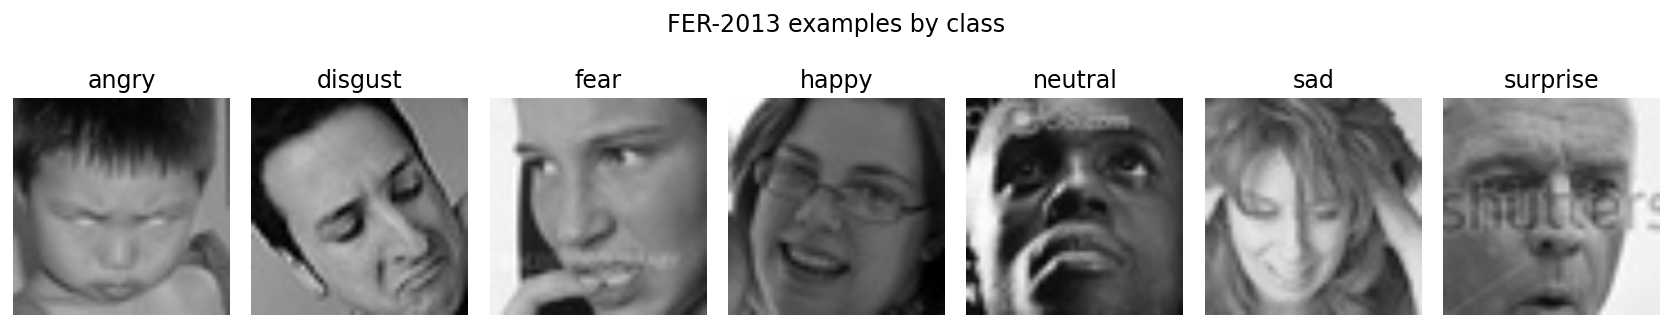

In [5]:
def first_example_per_class(dataset):
    selected = {}
    for idx, (_, label) in enumerate(dataset.samples):
        if label not in selected:
            selected[label] = idx
        if len(selected) == len(dataset.classes):
            break
    return [selected[i] for i in range(len(dataset.classes))]

example_indices = first_example_per_class(train_dataset)
fig, axes = plt.subplots(1, len(example_indices), figsize=(13, 2.4))
for ax, idx in zip(axes, example_indices):
    image_tensor, label = train_dataset[idx]
    ax.imshow(unnormalize_image(image_tensor), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")
fig.suptitle("FER-2013 examples by class", y=1.05)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fer2013_examples.png", bbox_inches="tight")
plt.show()

## Optional Model Fitting

The current checkpoint is much weaker on `angry`, `fear`, and `sad` than on easier classes such as `happy` and `surprise`. To test whether this is partly a training-objective problem, the optional fitting cell below uses a class-balanced sampler, class-weighted loss, stronger augmentation, and model selection by macro/weak-class validation accuracy rather than overall validation accuracy alone.

For stable blog figures, leave `RUN_TRAINING = False` unless you are intentionally running a new experiment. If a refit improves the weak classes, save it as a new checkpoint and rerun the evaluation cells below.


In [6]:
RUN_TRAINING = False
WEAK_CLASS_NAMES = {"angry", "fear", "sad"}
WEAK_CLASS_BOOST = 1.4


def subset_targets(subset):
    return np.array([subset.dataset.targets[i] for i in subset.indices], dtype=int)


def make_balanced_sampler(train_dataset, class_names):
    targets = subset_targets(train_dataset)
    counts = np.bincount(targets, minlength=len(class_names))
    class_weights = 1.0 / np.maximum(counts, 1)
    for idx, name in enumerate(class_names):
        if name in WEAK_CLASS_NAMES:
            class_weights[idx] *= WEAK_CLASS_BOOST
    sample_weights = class_weights[targets]
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    # Use the square root for the loss so sampling and loss weighting do not overcorrect too aggressively.
    loss_weights = np.sqrt(class_weights / class_weights.mean())
    return sampler, torch.as_tensor(loss_weights, dtype=torch.float32), counts


def evaluate_loader(model, loader, criterion, num_classes):
    model.eval()
    total_loss = 0.0
    total_seen = 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            total_seen += labels.size(0)
            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    per_class = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
    weak_indices = [i for i, name in enumerate(class_names) if name in WEAK_CLASS_NAMES]
    return {
        "loss": total_loss / total_seen,
        "acc": float((y_true == y_pred).mean()),
        "macro_acc": float(per_class.mean()),
        "weak_acc": float(per_class[weak_indices].mean()),
        "per_class_acc": per_class,
    }


def train_balanced_resnet18(train_dir, output_path, epochs=14, batch_size=32, learning_rate=2e-4, val_fraction=0.15):
    """Optional refit path aimed at improving angry/fear/sad performance."""
    full_train_aug = ImageFolder(train_dir, transform=build_training_transform())
    full_train_eval = ImageFolder(train_dir, transform=build_dataset_transform())
    val_size = int(len(full_train_aug) * val_fraction)
    train_size = len(full_train_aug) - val_size
    generator = torch.Generator().manual_seed(SEED)
    train_dataset, val_dataset = random_split(full_train_aug, [train_size, val_size], generator=generator)
    val_dataset.dataset = full_train_eval

    sampler, loss_weights, counts = make_balanced_sampler(train_dataset, full_train_aug.classes)
    print("training counts:", dict(zip(full_train_aug.classes, counts.tolist())))
    print("loss weights:", dict(zip(full_train_aug.classes, np.round(loss_weights.numpy(), 3))))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = create_resnet18(num_classes=len(full_train_aug.classes), pretrained=True).to(device)
    criterion = nn.CrossEntropyLoss(weight=loss_weights.to(device), label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_state = None
    best_score = -1.0
    best_epoch = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_seen = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * labels.size(0)
            train_correct += int((logits.argmax(dim=1) == labels).sum().item())
            train_seen += labels.size(0)
        scheduler.step()

        val_metrics = evaluate_loader(model, val_loader, criterion, len(full_train_aug.classes))
        score = 0.5 * val_metrics["macro_acc"] + 0.5 * val_metrics["weak_acc"]
        row = {
            "epoch": epoch,
            "train_loss": train_loss / train_seen,
            "train_acc": train_correct / train_seen,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_macro_acc": val_metrics["macro_acc"],
            "val_weak_acc": val_metrics["weak_acc"],
            "selection_score": score,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(row)
        print("  per-class:", dict(zip(full_train_aug.classes, np.round(val_metrics["per_class_acc"], 3))))

        if score > best_score:
            best_score = score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    checkpoint = {
        "architecture": "resnet18",
        "class_names": full_train_aug.classes,
        "state_dict": best_state,
        "best_epoch": best_epoch,
        "selection_metric": "0.5 * val_macro_acc + 0.5 * val_weak_acc",
        "selection_score": best_score,
        "dataset": "FER2013",
        "weak_classes": sorted(WEAK_CLASS_NAMES),
        "weak_class_boost": WEAK_CLASS_BOOST,
        "history": history,
    }
    torch.save(checkpoint, output_path)
    return checkpoint


if RUN_TRAINING:
    trained_checkpoint = train_balanced_resnet18(train_dir, MODEL_PATH)
    METADATA_PATH.write_text(json.dumps({k: v for k, v in trained_checkpoint.items() if k != "state_dict"}, indent=2))
    print("Saved refit checkpoint to", MODEL_PATH)
else:
    print("Skipping training and using the saved checkpoint. Set RUN_TRAINING=True to run the balanced refit experiment.")


Skipping training and using the saved checkpoint. Set RUN_TRAINING=True to refit in this notebook.


## Load Current Checkpoint

The final checkpoint stores both model weights and training metadata. The notebook can be extended to retrain the model, but loading the saved checkpoint keeps the final figures reproducible without requiring a long training run.

In [7]:
model, checkpoint = build_model(MODEL_PATH, device=device)

metadata = json.loads(METADATA_PATH.read_text()) if METADATA_PATH.exists() else {}
print("architecture:", checkpoint.get("architecture"))
print("validation accuracy:", metadata.get("val_accuracy", checkpoint.get("val_accuracy")))
print("test accuracy:", metadata.get("test_accuracy", checkpoint.get("test_accuracy")))
print("best epoch:", metadata.get("best_epoch", checkpoint.get("best_epoch")))


architecture: resnet18
validation accuracy: 0.6243324820060366
test accuracy: 0.6292839230983561
best epoch: 8


## Figure 2: Training History

This figure shows whether the final checkpoint improved through training and whether validation performance saturated before the original 70% target.

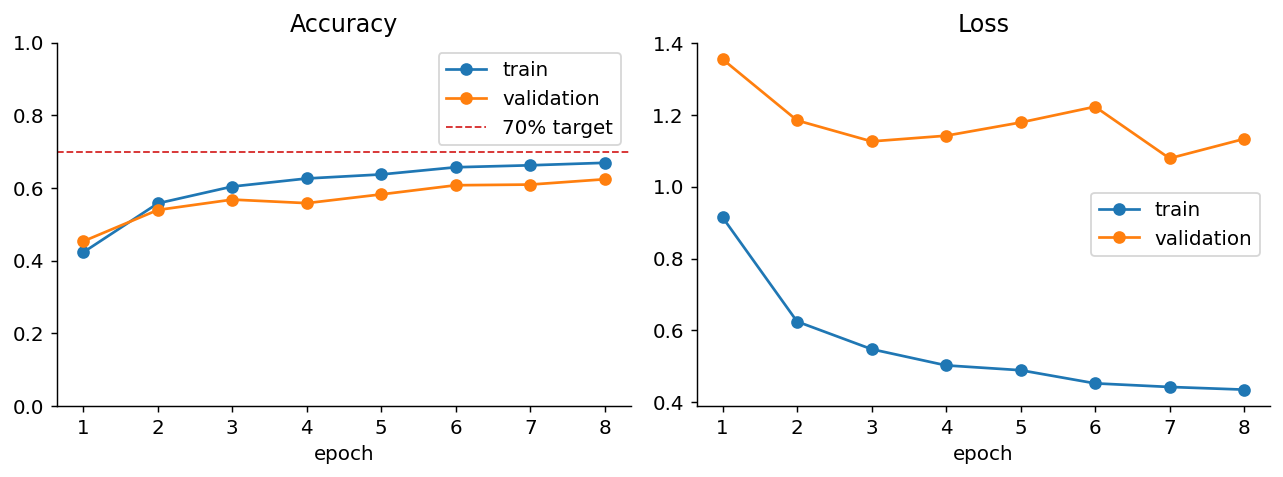

In [8]:
history = metadata.get("history", [])
if history:
    epochs = [row["epoch"] for row in history]
    train_acc = [row["train_acc"] for row in history]
    val_acc = [row["val_acc"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    val_loss = [row["val_loss"] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    axes[0].plot(epochs, train_acc, marker="o", label="train")
    axes[0].plot(epochs, val_acc, marker="o", label="validation")
    axes[0].axhline(0.70, color="tab:red", linestyle="--", linewidth=1, label="70% target")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylim(0, 1)
    axes[0].legend()

    axes[1].plot(epochs, train_loss, marker="o", label="train")
    axes[1].plot(epochs, val_loss, marker="o", label="validation")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "training_history.png", bbox_inches="tight")
    plt.show()
else:
    print("No history stored in checkpoint metadata.")

## Evaluate Test Set

The next cells compute predictions, confidences, and probabilities for the FER-2013 test set. Use `MAX_SAMPLES` for quick smoke tests while editing; set it to `None` for final figures.

In [9]:
MAX_SAMPLES = None

def collect_predictions(model, dataset, device, max_samples=None):
    model.eval()
    total = len(dataset) if max_samples is None else min(len(dataset), max_samples)
    y_true, y_pred, confidences, probabilities = [], [], [], []

    with torch.no_grad():
        for idx in range(total):
            image, label = dataset[idx]
            logits = model(image.unsqueeze(0).to(device))
            probs = torch.softmax(logits, dim=1).squeeze(0).detach().cpu().numpy()
            pred = int(np.argmax(probs))
            y_true.append(label)
            y_pred.append(pred)
            confidences.append(float(probs[pred]))
            probabilities.append(probs)

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(confidences),
        np.vstack(probabilities),
    )

y_true, y_pred, confidences, probabilities = collect_predictions(model, test_dataset, device, MAX_SAMPLES)
overall_accuracy = float((y_true == y_pred).mean())
overall_accuracy

0.6292839230983561

## Figures 3 and 4: Confusion Matrix and Per-Class Accuracy

A single overall accuracy number hides the system's most important failure modes. For assistive use, class-specific reliability matters more than leaderboard-style performance.

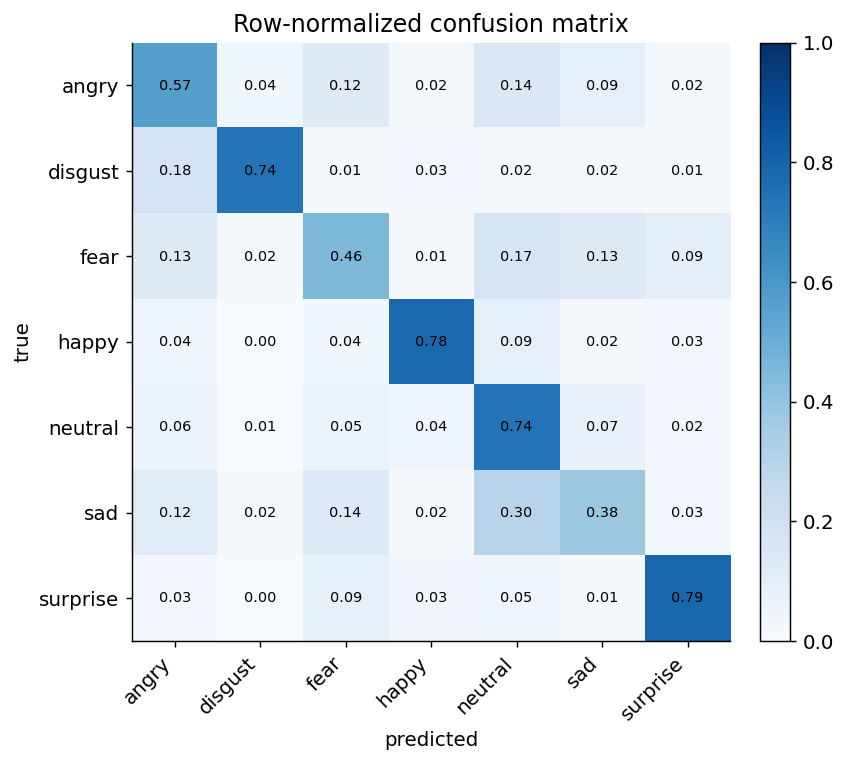

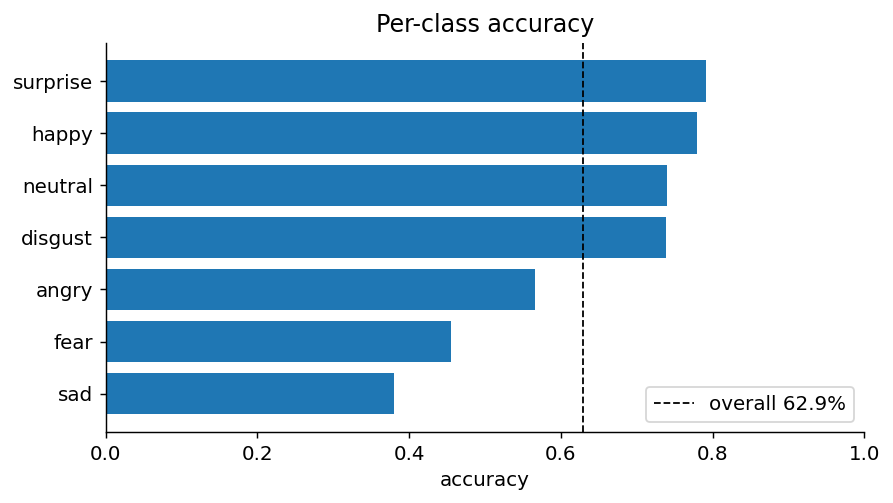

In [10]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names)), class_names)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Row-normalized confusion matrix")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confusion_matrix_normalized.png", bbox_inches="tight")
plt.show()

per_class_acc = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
order = np.argsort(per_class_acc)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(np.array(class_names)[order], per_class_acc[order], color="tab:blue")
ax.axvline(overall_accuracy, color="black", linestyle="--", linewidth=1, label=f"overall {overall_accuracy:.1%}")
ax.set_xlim(0, 1)
ax.set_xlabel("accuracy")
ax.set_title("Per-class accuracy")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "per_class_accuracy.png", bbox_inches="tight")
plt.show()

## Figure 5: Confidence Threshold Tradeoff

In a live assistive interface, the model does not need to label every frame. A confidence threshold trades coverage for reliability: higher thresholds produce fewer predictions, but the predictions that remain should be more accurate.

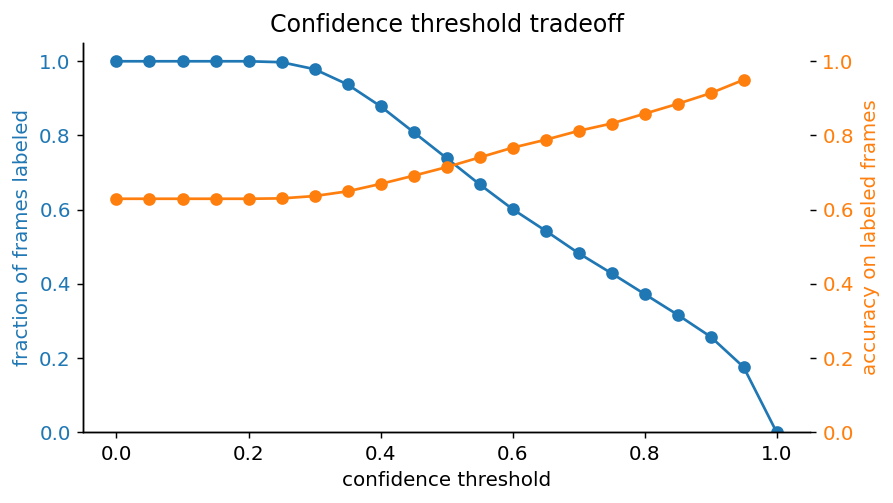

In [11]:
thresholds = np.linspace(0.0, 1.0, 21)
coverage = []
threshold_accuracy = []

correct = y_true == y_pred
for threshold in thresholds:
    keep = confidences >= threshold
    coverage.append(float(keep.mean()))
    threshold_accuracy.append(float(correct[keep].mean()) if keep.any() else np.nan)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(thresholds, coverage, marker="o", color="tab:blue", label="coverage")
ax1.set_xlabel("confidence threshold")
ax1.set_ylabel("fraction of frames labeled", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(thresholds, threshold_accuracy, marker="o", color="tab:orange", label="accuracy above threshold")
ax2.set_ylabel("accuracy on labeled frames", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(0, 1.05)

ax1.set_title("Confidence threshold tradeoff")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confidence_threshold_tradeoff.png", bbox_inches="tight")
plt.show()

## Figure 6: Reliability Diagram

This is a calibration-style diagnostic. If confidence were perfectly calibrated, examples predicted with 80% confidence would be correct about 80% of the time.

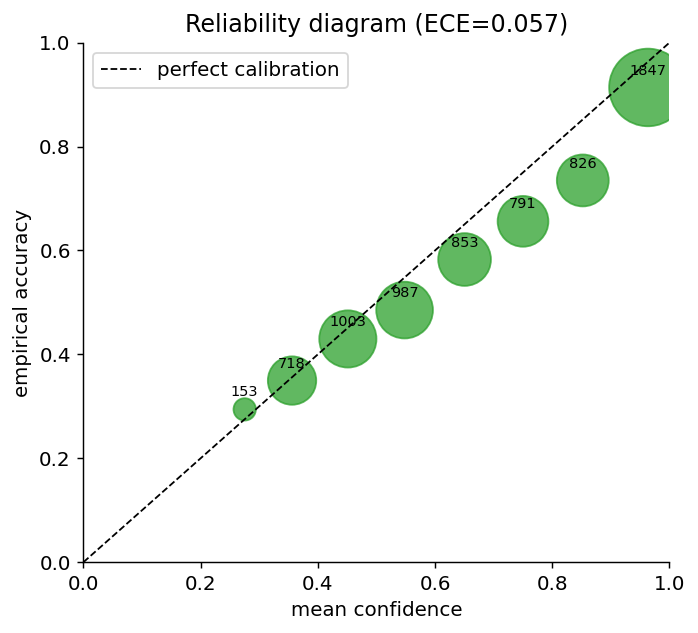

0.057373007963413866

In [12]:
bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(confidences, bins, right=True) - 1
bin_ids = np.clip(bin_ids, 0, len(bins) - 2)

bin_centers, bin_acc, bin_conf, bin_counts = [], [], [], []
ece = 0.0
for b in range(len(bins) - 1):
    mask = bin_ids == b
    if not mask.any():
        continue
    acc = float(correct[mask].mean())
    conf = float(confidences[mask].mean())
    count = int(mask.sum())
    bin_centers.append((bins[b] + bins[b + 1]) / 2)
    bin_acc.append(acc)
    bin_conf.append(conf)
    bin_counts.append(count)
    ece += (count / len(confidences)) * abs(acc - conf)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="perfect calibration")
ax.scatter(bin_conf, bin_acc, s=np.maximum(np.array(bin_counts), 10), alpha=0.75, color="tab:green")
for x, y, count in zip(bin_conf, bin_acc, bin_counts):
    ax.text(x, y + 0.025, str(count), ha="center", fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("mean confidence")
ax.set_ylabel("empirical accuracy")
ax.set_title(f"Reliability diagram (ECE={ece:.3f})")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "reliability_diagram.png", bbox_inches="tight")
plt.show()

ece

## Optional: Train a Fresh Model

The final blog should use the saved checkpoint above for stable figures. If we need to demonstrate fitting from scratch, set `RUN_TRAINING = True` in the optional fitting cell. The notebook keeps a compact training loop inline so the final branch has a single reproducibility artifact rather than separate analysis and training scripts.
